In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("Credit_Scoring_Dataset_100_Rows.csv")

In [3]:
df.head()

,Age,Sex,Job,Housing,Saving_Accounts,Checking_Account,Credit_Amount,Duration,Purpose,Income,Debt,Payment_History,Debt_to_Income_Ratio,Creditworthy
0,63,male,3,rent,quite rich,rich,6952,7,vacation,108671,76961,average,0.71,0
1,62,female,3,free,quite rich,moderate,7465,36,education,35310,19859,average,0.56,0
2,49,male,0,rent,rich,moderate,15585,25,vacation,117427,18189,good,0.15,1
3,31,female,0,own,rich,moderate,16060,41,business,32150,721,poor,0.02,1
4,45,male,1,own,quite rich,rich,3165,26,car,37016,6073,average,0.16,1


In [4]:
df.shape

(100, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   100 non-null    int64  
 1   Sex                   100 non-null    str    
 2   Job                   100 non-null    int64  
 3   Housing               100 non-null    str    
 4   Saving_Accounts       100 non-null    str    
 5   Checking_Account      100 non-null    str    
 6   Credit_Amount         100 non-null    int64  
 7   Duration              100 non-null    int64  
 8   Purpose               100 non-null    str    
 9   Income                100 non-null    int64  
 10  Debt                  100 non-null    int64  
 11  Payment_History       100 non-null    str    
 12  Debt_to_Income_Ratio  100 non-null    float64
 13  Creditworthy          100 non-null    int64  
dtypes: float64(1), int64(7), str(6)
memory usage: 11.1 KB


In [6]:
df.describe()

,Age,Job,Credit_Amount,Duration,Income,Debt,Debt_to_Income_Ratio,Creditworthy
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,43.140000,1.510000,10737.690000,37.130000,74511.000000,29367.050000,0.39570,0.510000
std,14.280749,1.096321,5788.138211,18.195157,26750.797107,21470.881836,0.23225,0.502418
min,18.000000,0.000000,659.000000,6.000000,27350.000000,25.000000,0.00000,0.000000
25%,32.500000,1.000000,5969.750000,23.000000,54364.250000,12586.000000,0.21000,0.000000
50%,43.500000,1.000000,11645.000000,33.000000,76714.000000,25824.000000,0.39000,1.000000
75%,56.000000,2.250000,15630.500000,51.250000,97690.500000,40700.500000,0.60000,1.000000
max,65.000000,3.000000,19957.000000,71.000000,119862.000000,94605.000000,0.79000,1.000000


In [7]:
df.isnull().sum()

Age                     0
Sex                     0
Job                     0
Housing                 0
Saving_Accounts         0
Checking_Account        0
Credit_Amount           0
Duration                0
Purpose                 0
Income                  0
Debt                    0
Payment_History         0
Debt_to_Income_Ratio    0
Creditworthy            0
dtype: int64

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,Age,Sex,Job,Housing,Saving_Accounts,Checking_Account,Credit_Amount,Duration,Purpose,Income,Debt,Payment_History,Debt_to_Income_Ratio,Creditworthy
0,63,male,3,rent,quite rich,rich,6952,7,vacation,108671,76961,average,0.71,0
1,62,female,3,free,quite rich,moderate,7465,36,education,35310,19859,average,0.56,0
2,49,male,0,rent,rich,moderate,15585,25,vacation,117427,18189,good,0.15,1
3,31,female,0,own,rich,moderate,16060,41,business,32150,721,poor,0.02,1
4,45,male,1,own,quite rich,rich,3165,26,car,37016,6073,average,0.16,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,34,male,2,rent,little,rich,16168,10,vacation,37983,25431,good,0.67,0
96,54,female,1,rent,quite rich,little,14187,47,home_appliance,111651,5731,poor,0.05,1
97,19,male,0,rent,little,rich,12969,23,car,90642,35460,good,0.39,1
98,47,male,1,rent,rich,little,16530,27,business,47326,31963,average,0.68,0


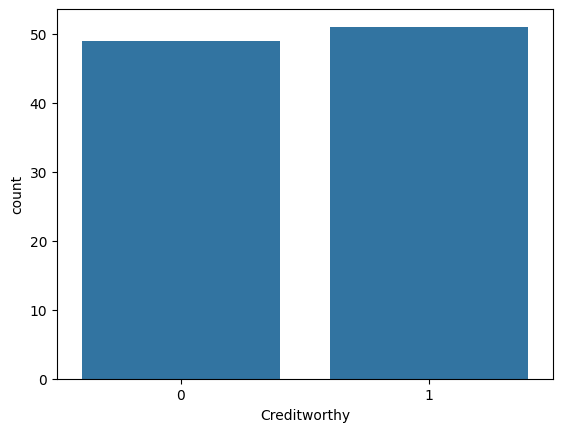

In [9]:
sns.countplot(x='Creditworthy', data=df)
plt.show()

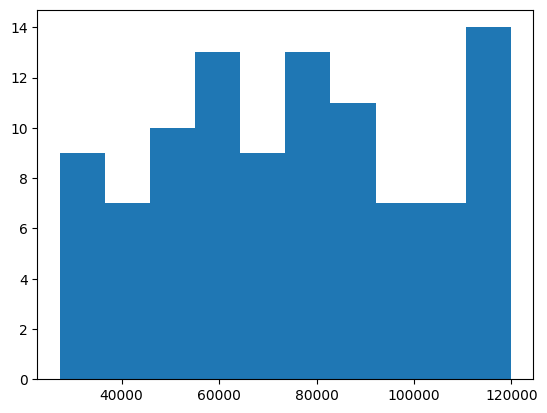

In [10]:
plt.hist(df['Income'])
plt.show()

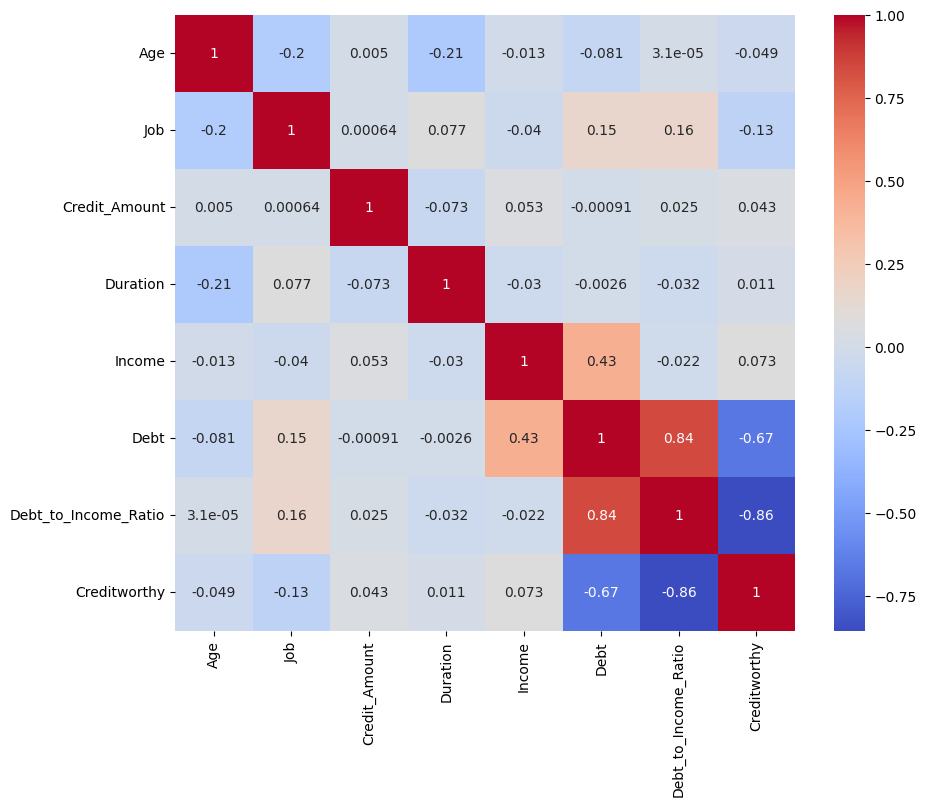

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

In [12]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

C:\Users\KIIT\AppData\Local\Temp\ipykernel_32488\302337938.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


In [13]:
df.head()

,Age,Sex,Job,Housing,Saving_Accounts,Checking_Account,Credit_Amount,Duration,Purpose,Income,Debt,Payment_History,Debt_to_Income_Ratio,Creditworthy
0,63,1,3,2,2,2,6952,7,4,108671,76961,0,0.71,0
1,62,0,3,0,2,1,7465,36,2,35310,19859,0,0.56,0
2,49,1,0,2,3,1,15585,25,4,117427,18189,1,0.15,1
3,31,0,0,1,3,1,16060,41,0,32150,721,2,0.02,1
4,45,1,1,1,2,2,3165,26,1,37016,6073,0,0.16,1


In [14]:
y = df['Creditworthy']

In [15]:
X = df.drop('Creditworthy', axis=1)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [18]:
y_pred = lr.predict(X_test)

In [19]:
accuracy_score(y_test, y_pred)

1.0

In [21]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_score(y_test, y_pred_dt)

1.0

In [22]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_score(y_test, y_pred_rf)

1.0

In [23]:
print("Logistic Regression:",
      accuracy_score(y_test,y_pred))

print("Decision Tree:",
      accuracy_score(y_test,y_pred_dt))

print("Random Forest:",
      accuracy_score(y_test,y_pred_rf))

Logistic Regression: 1.0
Decision Tree: 1.0
Random Forest: 1.0


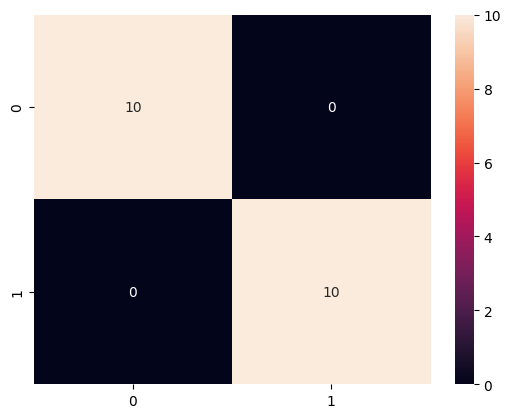

In [24]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.show()

In [25]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [26]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
12  Debt_to_Income_Ratio    0.498097
10                  Debt    0.234844
9                 Income    0.050970
6          Credit_Amount    0.048067
7               Duration    0.036718
4        Saving_Accounts    0.029278
0                    Age    0.028508
8                Purpose    0.024399
2                    Job    0.014994
11       Payment_History    0.014250
3                Housing    0.010181
5       Checking_Account    0.005373
1                    Sex    0.004323


In [27]:
import joblib

joblib.dump(
    rf,
    "credit_scoring_model.pkl"
)

['credit_scoring_model.pkl']